<a href="https://colab.research.google.com/github/minafathima49-bot/disease-prediction-system/blob/main/disease_prediction_system.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
import pandas as pd

csv_url="https://github.com/minafathima49-bot/disease-prediction-system/raw/refs/heads/main/Testing.csv"
test_df = pd.read_csv(csv_url)
csv_url="https://github.com/minafathima49-bot/disease-prediction-system/raw/refs/heads/main/Training.csv"
train_df = pd.read_csv(csv_url)




In [3]:
print("Training shape:", train_df.shape)
print("Testing shape:", test_df.shape)

print("\nTraining data:")
display(train_df.head())

print("\nTesting data:")
display(test_df.head())

print("\nMissing values in training:")
print(train_df.isnull().sum().sum())

print("\nTarget column:")
print(train_df.columns[-1])

Training shape: (4920, 134)
Testing shape: (42, 133)

Training data:


,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze,prognosis,Unnamed: 133
0,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN
1,0,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN
2,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN
3,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN
4,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN



Testing data:


,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,blackheads,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze,prognosis
0,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
1,0,0,0,1,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Allergy
2,0,0,0,0,0,0,0,1,1,1,...,0,0,0,0,0,0,0,0,0,GERD
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Chronic cholestasis
4,1,1,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,Drug Reaction



Missing values in training:
4920

Target column:
Unnamed: 133


In [4]:
train_df = train_df.loc[:, ~train_df.columns.str.contains('^Unnamed')]
test_df = test_df.loc[:, ~test_df.columns.str.contains('^Unnamed')]

print("Training shape after cleaning:", train_df.shape)
print("Testing shape after cleaning:", test_df.shape)

print("\nLast 5 training columns:")
print(train_df.columns[-5:].tolist())

print("\nMissing values in training:")
print(train_df.isnull().sum().sum())

print("\nMissing values in testing:")
print(test_df.isnull().sum().sum())

Training shape after cleaning: (4920, 133)
Testing shape after cleaning: (42, 133)

Last 5 training columns:
['inflammatory_nails', 'blister', 'red_sore_around_nose', 'yellow_crust_ooze', 'prognosis']

Missing values in training:
0

Missing values in testing:
0


In [5]:
print("Last column:", train_df.columns[-1])
print("\nDisease values:")
print(train_df[train_df.columns[-1]].unique())

Last column: prognosis

Disease values:
['Fungal infection' 'Allergy' 'GERD' 'Chronic cholestasis' 'Drug Reaction'
 'Peptic ulcer diseae' 'AIDS' 'Diabetes ' 'Gastroenteritis'
 'Bronchial Asthma' 'Hypertension ' 'Migraine' 'Cervical spondylosis'
 'Paralysis (brain hemorrhage)' 'Jaundice' 'Malaria' 'Chicken pox'
 'Dengue' 'Typhoid' 'hepatitis A' 'Hepatitis B' 'Hepatitis C'
 'Hepatitis D' 'Hepatitis E' 'Alcoholic hepatitis' 'Tuberculosis'
 'Common Cold' 'Pneumonia' 'Dimorphic hemmorhoids(piles)' 'Heart attack'
 'Varicose veins' 'Hypothyroidism' 'Hyperthyroidism' 'Hypoglycemia'
 'Osteoarthristis' 'Arthritis' '(vertigo) Paroymsal  Positional Vertigo'
 'Acne' 'Urinary tract infection' 'Psoriasis' 'Impetigo']


In [244]:
print("Number of diseases:", train_df['prognosis'].nunique())

print("\nDisease distribution:")
print(train_df['prognosis'].value_counts())

Number of diseases: 41

Disease distribution:
prognosis
Fungal infection                           120
Allergy                                    120
GERD                                       120
Chronic cholestasis                        120
Drug Reaction                              120
Peptic ulcer diseae                        120
AIDS                                       120
Diabetes                                   120
Gastroenteritis                            120
Bronchial Asthma                           120
Hypertension                               120
Migraine                                   120
Cervical spondylosis                       120
Paralysis (brain hemorrhage)               120
Jaundice                                   120
Malaria                                    120
Chicken pox                                120
Dengue                                     120
Typhoid                                    120
hepatitis A                                120
Hepa

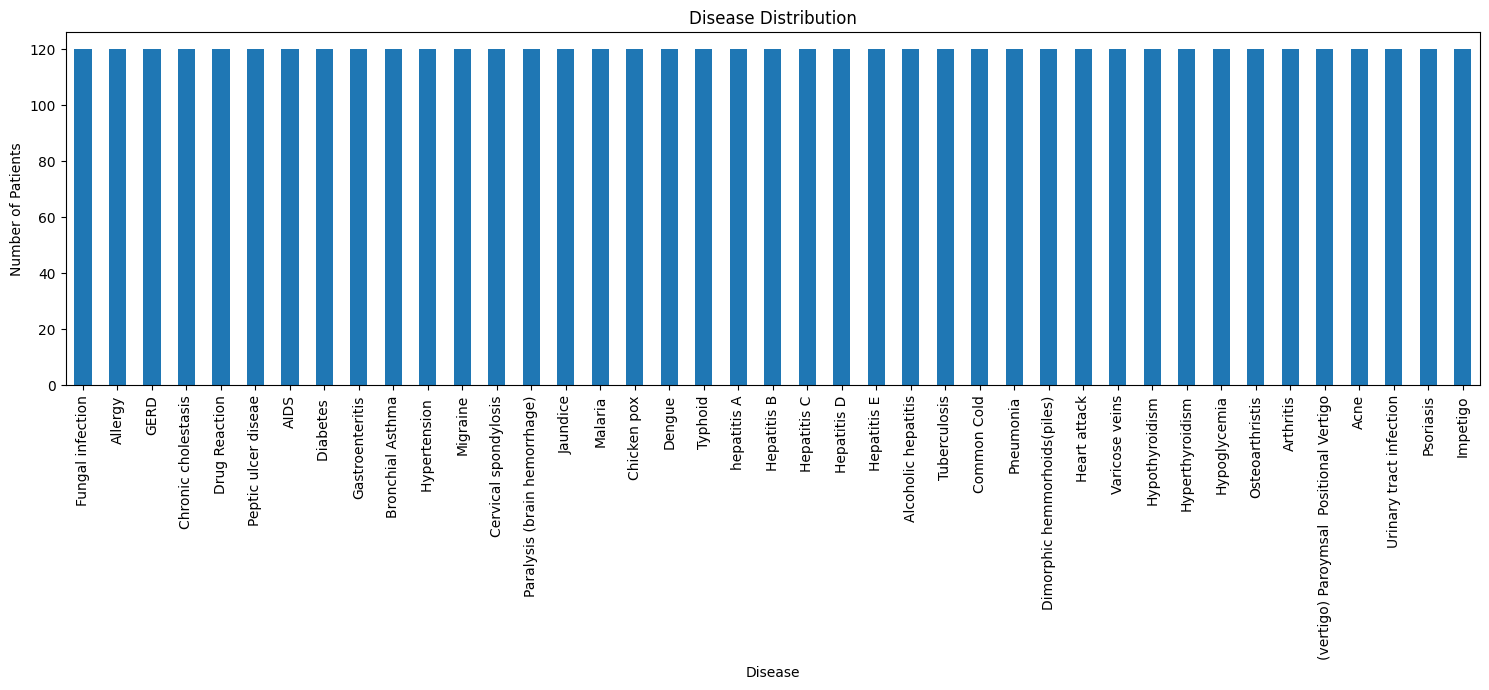

In [243]:
plt.figure(figsize=(15, 7))

train_df['prognosis'].value_counts().plot(kind='bar')

plt.title("Disease Distribution")
plt.xlabel("Disease")
plt.ylabel("Number of Patients")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [241]:
symptom_columns = train_df.columns[:-1]

symptom_frequency = train_df[symptom_columns].sum().sort_values(ascending=False)

print("Most common symptoms:")
print(symptom_frequency.head(20))

Most common symptoms:
fatigue              1932
vomiting             1914
high_fever           1362
loss_of_appetite     1152
nausea               1146
headache             1134
abdominal_pain       1032
yellowish_skin        912
yellowing_of_eyes     816
chills                798
skin_rash             786
malaise               702
chest_pain            696
joint_pain            684
itching               678
sweating              678
dark_urine            570
cough                 564
diarrhoea             564
muscle_pain           474
dtype: int64


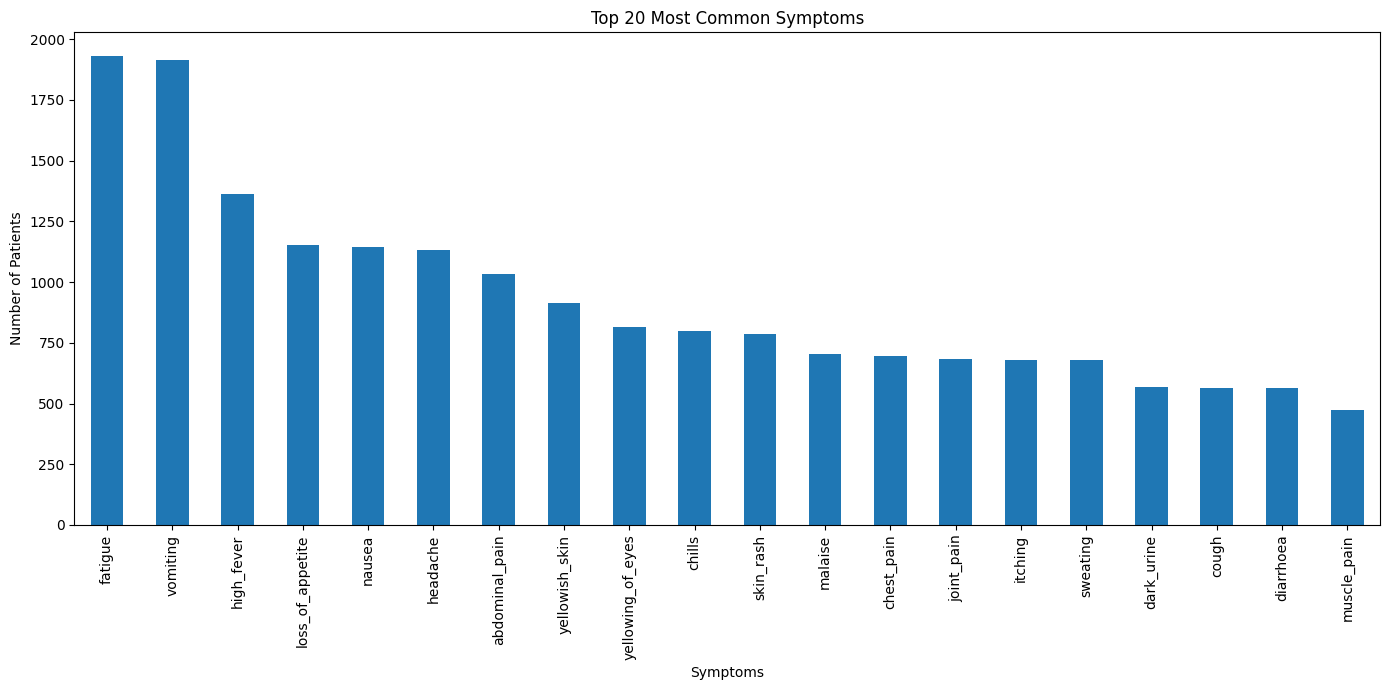

In [242]:
plt.figure(figsize=(14, 7))

symptom_frequency.head(20).plot(kind='bar')

plt.title("Top 20 Most Common Symptoms")
plt.xlabel("Symptoms")
plt.ylabel("Number of Patients")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [245]:
print(train_df.dtypes.value_counts())

int64     132
object      1
Name: count, dtype: int64


In [246]:
print("Non-numeric columns:")
print(train_df.select_dtypes(exclude='number').columns.tolist())

Non-numeric columns:
['prognosis']


In [247]:
X_train = train_df.drop(columns=['prognosis'])
y_train = train_df['prognosis']

X_test = test_df.drop(columns=['prognosis'])
y_test = test_df['prognosis']

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (4920, 132)
y_train: (4920,)
X_test: (42, 132)
y_test: (42,)


In [248]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),
    "Naive Bayes": GaussianNB(),
    "SVM": SVC()
}

print("5 models selected successfully!")

5 models selected successfully!


In [249]:
trained_models = {}

for name, model in models.items():
    print("Training:", name)

    model.fit(X_train, y_train)

    trained_models[name] = model

    print(name, "trained successfully!\n")

print("All 5 models trained successfully!")

Training: Logistic Regression
Logistic Regression trained successfully!

Training: Decision Tree
Decision Tree trained successfully!

Training: Random Forest
Random Forest trained successfully!

Training: Naive Bayes
Naive Bayes trained successfully!

Training: SVM
SVM trained successfully!

All 5 models trained successfully!


In [250]:
predictions = {}

for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    predictions[name] = y_pred

    print(name, "prediction completed!")

print("\nAll predictions completed successfully!")

Logistic Regression prediction completed!
Decision Tree prediction completed!
Random Forest prediction completed!
Naive Bayes prediction completed!
SVM prediction completed!

All predictions completed successfully!


In [263]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,confusion_matrix

for name in trained_models:

    y_pred = predictions[name]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    print(name)

    print("Accuracy :", accuracy)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1-Score :", f1)


    print(" CONFUSION MATRIX ")
    print(f"True Positives (TP):  {cm[1][1]}")
    print(f"False Negatives (FN): {cm[1][0]}")
    print(f"False Positives (FP): {cm[0][1]}")
    print(f"True Negatives (TN):  {cm[0][0]}")

    print()

Logistic Regression
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1-Score : 1.0
 CONFUSION MATRIX 
True Positives (TP):  5
False Negatives (FN): 6
False Positives (FP): 7
True Negatives (TN):  11

Decision Tree
Accuracy : 0.9761904761904762
Precision: 0.9880952380952381
Recall   : 0.9761904761904762
F1-Score : 0.9761904761904762
 CONFUSION MATRIX 
True Positives (TP):  5
False Negatives (FN): 6
False Positives (FP): 7
True Negatives (TN):  11

Random Forest
Accuracy : 0.9761904761904762
Precision: 0.9880952380952381
Recall   : 0.9761904761904762
F1-Score : 0.9761904761904762
 CONFUSION MATRIX 
True Positives (TP):  5
False Negatives (FN): 6
False Positives (FP): 7
True Negatives (TN):  11

Naive Bayes
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1-Score : 1.0
 CONFUSION MATRIX 
True Positives (TP):  5
False Negatives (FN): 6
False Positives (FP): 7
True Negatives (TN):  11

SVM
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1-Score : 1.0
 CONFUSION MATRIX 
True Positives (TP):  5
False